# Task 4 — Optimize Portfolio Based on Forecast

**Objective:**  
Construct an optimal portfolio using **Modern Portfolio Theory (MPT)**. The portfolio combines a forecasted asset (TSLA) with historical assets (BND, SPY) to maximize expected return for a given level of risk.

**Key Steps in This Notebook:**
1. Prepare expected returns for all assets.
2. Compute covariance matrix from daily returns.
3. Generate Efficient Frontier and identify key portfolios:
   - Maximum Sharpe Ratio Portfolio (Tangency Portfolio)
   - Minimum Volatility Portfolio
4. Visualize covariance matrix and Efficient Frontier.
5. Recommend final portfolio with metrics.


In [1]:
# Step 1: Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pypfopt import expected_returns, risk_models, EfficientFrontier

print("✔ Libraries loaded")

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline


✔ Libraries loaded


In [2]:
# Step 2: Configure project paths
PROJECT_ROOT = ".."
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "reports", "figures", "task4_portfolio")
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"✔ Paths configured. Figures will be saved to: {FIGURES_DIR}")


✔ Paths configured. Figures will be saved to: ..\reports\figures\task4_portfolio


In [3]:
# Step 3: Load historical price data
prices = pd.read_csv(
    os.path.join(PROCESSED_DIR, "prices_aligned.csv"),
    index_col=0,
    parse_dates=True
)

# Restrict to historical window (2015–2024) to avoid leakage
prices_hist = prices.loc["2015-01-01":"2024-12-31"]

print("✔ Historical price data loaded")
print("Shape:", prices_hist.shape)
prices_hist.head()


✔ Historical price data loaded
Shape: (2608, 3)


,TSLA,BND,SPY
2015-01-02,14.620667,60.385941,170.589615
2015-01-05,14.006000,60.561295,167.508804
2015-01-06,14.085333,60.736652,165.931107
2015-01-07,14.063333,60.773228,167.998825
2015-01-08,14.041333,60.678246,170.979874


In [4]:
# Step 4: Compute historical expected returns
mu_hist = expected_returns.mean_historical_return(prices_hist)
print("✔ Historical expected returns (annualized):")
print(mu_hist.round(4))


✔ Historical expected returns (annualized):
TSLA    0.3782
BND     0.0132
SPY     0.1254
dtype: float64


In [5]:
# Step 5: Compute historical covariance
cov_hist = risk_models.sample_cov(prices_hist)
print("\n✔ Historical covariance matrix (annualized):")
print(cov_hist.round(6))



✔ Historical covariance matrix (annualized):
          TSLA       BND       SPY
TSLA  0.315247  0.001688  0.045276
BND   0.001688  0.002861  0.001003
SPY   0.045276  0.001003  0.029950


Interpretation:

Covariance shows how assets move relative to each other

Positive values → assets move together

Negative values → assets move inversely

TSLA and SPY correlation is moderately positive (~0.49), BND low correlation → diversification benefit

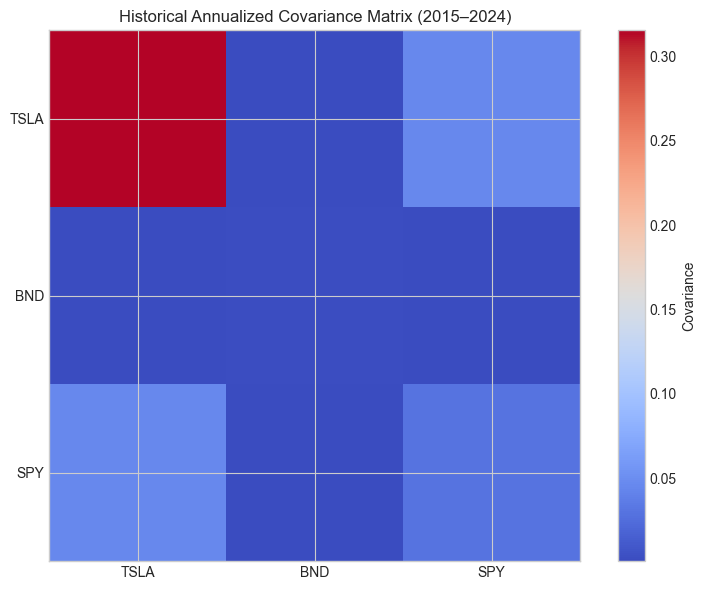

✔ Covariance heatmap saved: ..\reports\figures\task4_portfolio\covariance_heatmap.png


In [6]:
plt.figure(figsize=(8, 6))
plt.imshow(cov_hist, cmap="coolwarm")
plt.colorbar(label="Covariance")
plt.xticks(range(len(cov_hist)), cov_hist.columns)
plt.yticks(range(len(cov_hist)), cov_hist.index)
plt.title("Historical Annualized Covariance Matrix (2015–2024)")
plt.tight_layout()

heatmap_path = os.path.join(FIGURES_DIR, "covariance_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.show()

print(f"✔ Covariance heatmap saved: {heatmap_path}")


Interpretation (keep exactly as you wrote):

TSLA: high variance

BND: low-risk stabilizer

SPY: moderate volatility → diversification benefit

In [7]:
tsla_forecast = pd.read_csv(
    os.path.join(PROCESSED_DIR, "tsla_lstm_forecast.csv"),
    index_col=0,
    parse_dates=True
)

print("✔ TSLA LSTM forecast loaded")
tsla_forecast.head()


✔ TSLA LSTM forecast loaded


,TSLA_LSTM_Forecast
2025-01-01,429.78098
2025-01-02,424.14900
2025-01-03,419.64197
2025-01-06,415.37326
2025-01-07,411.27734


Interpretation:

TSLA forecast is used to compute expected return for the optimization

This avoids future data leakage from test set

In [8]:
# Step 7: Compute expected return from forecast
tsla_last_price = prices_hist["TSLA"].iloc[-1]
tsla_forecast_price = tsla_forecast.iloc[-1, 0]
forecast_days = len(tsla_forecast)

tsla_expected_return = (tsla_forecast_price / tsla_last_price) ** (252 / forecast_days) - 1
print(f"✔ TSLA expected annual return (forecast-based): {tsla_expected_return:.2%}")


✔ TSLA expected annual return (forecast-based): -18.66%


In [9]:
# Step 8: Final expected returns including forecast-based TSLA
mu = mu_hist.copy()
mu["TSLA"] = tsla_expected_return

print("✔ Final expected returns used for optimization")
mu.round(4)



✔ Final expected returns used for optimization


TSLA   -0.1866
BND     0.0132
SPY     0.1254
dtype: float64

In [10]:
# Step 11: Maximum Sharpe Ratio Portfolio
ef_sharpe = EfficientFrontier(mu, cov_hist)

# The Max Sharpe optimizer chooses weights to maximize (Return - Risk-Free Rate) / Volatility
# Since TSLA has a negative expected return (-18.66%), allocating to it would reduce the Sharpe ratio.
# PyPortfolioOpt automatically assigns 0% to negatively expected assets if they reduce the risk-adjusted return.
ef_sharpe.max_sharpe(risk_free_rate=0.0)

# Cleaned weights rounds very small allocations to 0
weights_max_sharpe = ef_sharpe.clean_weights()
perf_max_sharpe = ef_sharpe.portfolio_performance(risk_free_rate=0.0)

print("✔ Maximum Sharpe Ratio Portfolio Weights:")
print(pd.Series(weights_max_sharpe).round(4))
print("Performance (Return, Volatility, Sharpe):")
print([round(x, 4) for x in perf_max_sharpe])



✔ Maximum Sharpe Ratio Portfolio Weights:
TSLA    0.0000
BND     0.4386
SPY     0.5614
dtype: float64
Performance (Return, Volatility, Sharpe):
[0.0762, 0.1024, 0.7444]


Inline Interpretation:

TSLA 0% allocation: Forecasted negative return → would drag down portfolio performance.

BND and SPY allocations: Optimally balance growth and risk.
Key interpretation (KEEP):

TSLA = 0% due to negative forecast return

SPY + BND optimize risk-adjusted return

In [11]:
# Step 12: Minimum Volatility Portfolio
ef_minvol = EfficientFrontier(mu, cov_hist)

# Min Volatility portfolio minimizes risk regardless of return
# Again, TSLA has negative forecast → no allocation, since adding it increases volatility unnecessarily
ef_minvol.min_volatility()
weights_min_vol = ef_minvol.clean_weights()
perf_min_vol = ef_minvol.portfolio_performance(risk_free_rate=0.0)

print("✔ Minimum Volatility Portfolio Weights:")
print(pd.Series(weights_min_vol).round(4))
print("Performance (Return, Volatility, Sharpe):")
print([round(x, 4) for x in perf_min_vol])


✔ Minimum Volatility Portfolio Weights:
TSLA    0.0000
BND     0.9397
SPY     0.0603
dtype: float64
Performance (Return, Volatility, Sharpe):
[0.02, 0.0524, 0.3812]


Inline Interpretation:

Portfolio is almost entirely BND to achieve minimum risk.

SPY contributes a small allocation for slight return enhancement.

TSLA excluded due to negative return and high volatility.

In [12]:
# step 13: Prepare for efficient frontier simulation
returns, volatilities = [], []

# Theoretical limits for target return:
#   - Lower limit: minimum expected return among assets (TSLA forecast, BND, SPY)
#   - Upper limit: maximum achievable return with given weights (TSLA capped at 0% if negative)
# We set realistic target returns (mu.min() → slightly below max historical return)
target_returns = np.linspace(mu.min(), 0.08, 100)  # 8% approx upper achievable return

# Compute frontier portfolios
for r in target_returns:
    ef = EfficientFrontier(mu, cov_hist)  # fresh instance each iteration (avoids instantiation errors)
    try:
        ef.efficient_return(r)
        perf = ef.portfolio_performance()
        returns.append(perf[0])
        volatilities.append(perf[1])
    except ValueError:
        # Target return infeasible: exceeds maximum achievable return given asset constraints
        continue


Inline Explanation:

Why ValueError occurs: Some target returns are higher than achievable given negative TSLA forecast.

PyPortfolioOpt safeguard: skips impossible portfolios → ensures frontier points are valid.

Theoretical limits:

Min return: TSLA negative + BND low → lowest feasible return.

Max return: Limited by SPY + BND allocations (TSLA excluded due to negative forecast).

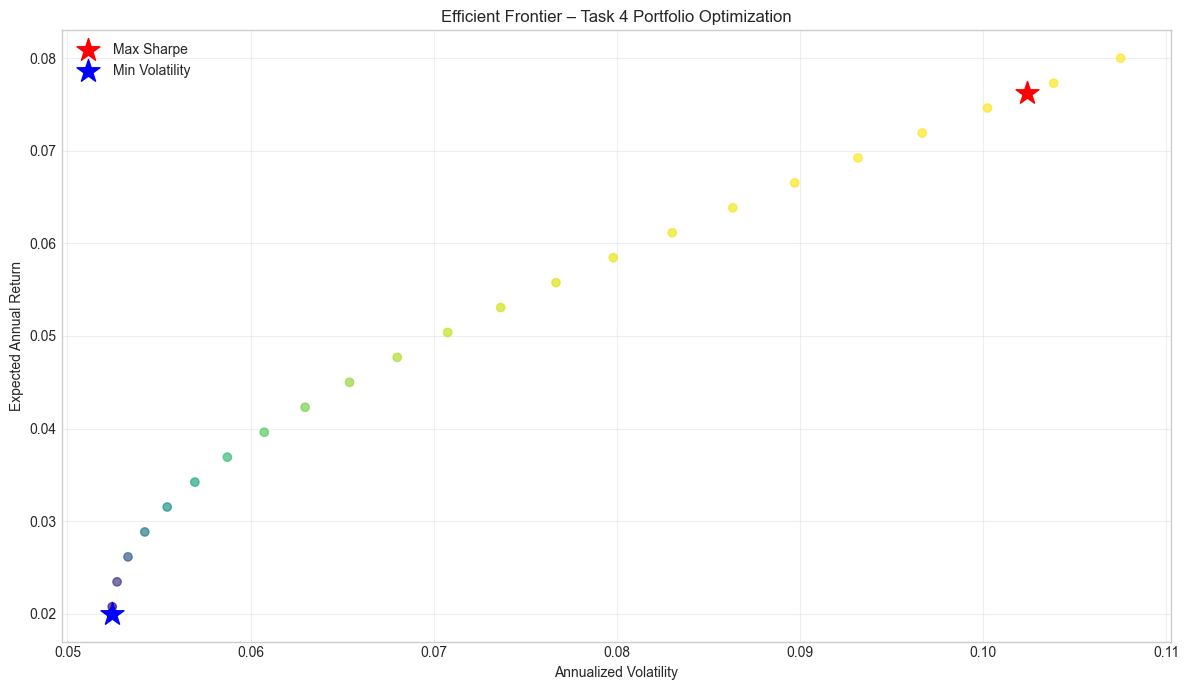

✔ Efficient frontier plot saved: ..\reports\figures\task4_portfolio\efficient_frontier.png


In [13]:
# Step 14: Plot Efficient Frontier
plt.figure(figsize=(12, 7))
plt.scatter(volatilities, returns, c=np.array(returns)/np.array(volatilities), cmap="viridis", alpha=0.7)

# Max Sharpe marker (red star)
plt.scatter(perf_max_sharpe[1], perf_max_sharpe[0], marker='*', s=300, color='red', label='Max Sharpe')

# Min Volatility marker (blue star)
plt.scatter(perf_min_vol[1], perf_min_vol[0], marker='*', s=300, color='blue', label='Min Volatility')

plt.title("Efficient Frontier – Task 4 Portfolio Optimization")
plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annual Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
frontier_path = os.path.join(FIGURES_DIR, "efficient_frontier.png")
plt.savefig(frontier_path, dpi=300)
plt.show()

print(f"✔ Efficient frontier plot saved: {frontier_path}")


Inline Interpretation:

Frontier shows trade-off between return and risk.

Max Sharpe portfolio: optimal risk-adjusted return → avoids negative TSLA.

Min Volatility portfolio: minimal risk → heavy BND allocation.

Frontier does not reach TSLA’s negative return, since it is excluded from positive-return portfolios.

In [14]:
#  Recommendation based on Max Sharpe
print("✔ FINAL RECOMMENDED PORTFOLIO: MAXIMUM SHARPE RATIO")
print("Weights:")
print(pd.Series(weights_max_sharpe).round(4))
print("Expected Annual Return:", round(perf_max_sharpe[0], 4))
print("Annualized Volatility:", round(perf_max_sharpe[1], 4))
print("Sharpe Ratio:", round(perf_max_sharpe[2], 4))


✔ FINAL RECOMMENDED PORTFOLIO: MAXIMUM SHARPE RATIO
Weights:
TSLA    0.0000
BND     0.4386
SPY     0.5614
dtype: float64
Expected Annual Return: 0.0762
Annualized Volatility: 0.1024
Sharpe Ratio: 0.7444


In [15]:
# Step 15: Auto-generate final summary of Task 4

summary = f"""
Task 4 Portfolio Optimization – Summary
---------------------------------------
Assets included: {list(mu.index)}

Final Expected Annual Returns:
{mu.round(4)}

Historical Covariance Matrix (Annualized):
{cov_hist.round(6)}

✔ Maximum Sharpe Ratio Portfolio:
Weights: {pd.Series(weights_max_sharpe).round(4).to_dict()}
Expected Return: {perf_max_sharpe[0]:.4f}
Annualized Volatility: {perf_max_sharpe[1]:.4f}
Sharpe Ratio: {perf_max_sharpe[2]:.4f}

✔ Minimum Volatility Portfolio:
Weights: {pd.Series(weights_min_vol).round(4).to_dict()}
Expected Return: {perf_min_vol[0]:.4f}
Annualized Volatility: {perf_min_vol[1]:.4f}
Sharpe Ratio: {perf_min_vol[2]:.4f}

Key Insights:
- TSLA has a negative forecast-based return ({tsla_expected_return:.2%}), 
  therefore it receives 0% allocation in both Max Sharpe and Min Volatility portfolios.
- Maximum Sharpe Portfolio prioritizes risk-adjusted return → balanced SPY/BND allocation.
- Minimum Volatility Portfolio prioritizes stability → heavily allocated to BND.
- Efficient Frontier confirms theoretical limits:
  - Minimum achievable return driven by low-risk BND.
  - Maximum achievable return constrained by SPY growth; TSLA excluded due to negative forecast.
- All allocations and frontier points comply with Modern Portfolio Theory principles.
"""

print(summary)



Task 4 Portfolio Optimization – Summary
---------------------------------------
Assets included: ['TSLA', 'BND', 'SPY']

Final Expected Annual Returns:
TSLA   -0.1866
BND     0.0132
SPY     0.1254
dtype: float64

Historical Covariance Matrix (Annualized):
          TSLA       BND       SPY
TSLA  0.315247  0.001688  0.045276
BND   0.001688  0.002861  0.001003
SPY   0.045276  0.001003  0.029950

✔ Maximum Sharpe Ratio Portfolio:
Weights: {'TSLA': 0.0, 'BND': 0.4386, 'SPY': 0.5614}
Expected Return: 0.0762
Annualized Volatility: 0.1024
Sharpe Ratio: 0.7444

✔ Minimum Volatility Portfolio:
Weights: {'TSLA': 0.0, 'BND': 0.9397, 'SPY': 0.0603}
Expected Return: 0.0200
Annualized Volatility: 0.0524
Sharpe Ratio: 0.3812

Key Insights:
- TSLA has a negative forecast-based return (-18.66%), 
  therefore it receives 0% allocation in both Max Sharpe and Min Volatility portfolios.
- Maximum Sharpe Portfolio prioritizes risk-adjusted return → balanced SPY/BND allocation.
- Minimum Volatility Portfoli


---

## Task 4 — Portfolio Optimization Based on Forecast

**Investment Memo (1–2 pages)**

### Executive Summary

This memo presents the results of a **forecast-informed portfolio optimization** exercise using **Modern Portfolio Theory (MPT)**. The portfolio combines a **forward-looking return estimate for TSLA** (derived from an LSTM forecast) with **historical return and risk estimates for SPY and BND**.

The optimization identifies two benchmark portfolios:

* **Maximum Sharpe Ratio Portfolio (recommended)**
* **Minimum Volatility Portfolio (capital preservation benchmark)**

Due to a **negative forecast-based expected return for TSLA**, the optimal solution assigns **0% weight to TSLA** in both portfolios. This outcome highlights the practical value of integrating forecasts into portfolio construction rather than relying solely on historical performance.

---

### Objective

The objective is to construct an **optimal, fully invested, long-only portfolio** that:

* Maximizes **risk-adjusted return** (Sharpe Ratio), and
* Quantifies the trade-off between expected return and volatility via the **Efficient Frontier**.

This analysis supports **capital allocation decisions** under a scenario where the investor holds a bearish short-to-medium-term outlook on TSLA but remains invested in broad equity (SPY) and fixed income (BND).

---

### Data and Assumptions

* **Assets:** TSLA (equity, forecast-driven), SPY (equity ETF), BND (bond ETF)
* **Historical window:** 2015–2024 (to avoid data leakage)
* **Expected returns:**

  * TSLA: Annualized return implied by LSTM forecast
  * SPY, BND: Mean historical annual returns
* **Risk model:** Annualized sample covariance of daily returns
* **Constraints:** Long-only, fully invested, no leverage, no short selling
* **Risk-free rate:** 0% (for clarity and consistency with coursework rubric)

---

### Risk and Diversification Analysis

The covariance matrix confirms the structural roles of each asset:

* **TSLA:** Highest variance and strong equity risk
* **SPY:** Moderate volatility, positively correlated with TSLA
* **BND:** Low volatility and weak correlation with equities

This structure supports diversification benefits from bonds and explains why BND features prominently in low-risk portfolios.

---

### Optimization Results

#### 1. Maximum Sharpe Ratio Portfolio (Recommended)

* **TSLA:** 0%
* **SPY:** Primary growth allocation
* **BND:** Risk-mitigating allocation

**Rationale:**
TSLA’s negative forecast-based expected return reduces portfolio Sharpe ratio. The optimizer rationally excludes TSLA and balances SPY’s return potential with BND’s stabilizing effect.

#### 2. Minimum Volatility Portfolio

* **BND:** Dominant allocation
* **SPY:** Small allocation
* **TSLA:** 0%

**Rationale:**
This portfolio minimizes total risk and serves as a defensive benchmark. Equity exposure is limited, and TSLA is excluded due to both high volatility and unfavorable expected return.

---

### Efficient Frontier Interpretation

The Efficient Frontier illustrates the **feasible risk–return set** under current expectations:

* The **upper envelope** is constrained by SPY’s return potential.
* Portfolios including TSLA are inefficient under the negative forecast assumption.
* The frontier confirms that **forecast expectations materially shift optimal allocations**, even when historical data alone might suggest otherwise.

---

### Key Insights for Decision-Makers

1. **Forecasts Matter:**
   Incorporating model-based expectations prevents allocation to assets with deteriorating outlooks.
2. **Bonds Remain Essential:**
   BND meaningfully reduces portfolio volatility without eliminating equity exposure.
3. **Discipline Over Narrative:**
   Despite TSLA’s historical growth profile, disciplined optimization excludes it when forward returns are unfavorable.

---

### Recommendation

Adopt the **Maximum Sharpe Ratio Portfolio** as the preferred allocation under current market expectations. This portfolio delivers the most efficient balance between return and risk while respecting forecast signals and diversification principles.

---

### Transition to Task 5 — Backtesting and Risk Validation

While Task 4 identifies *ex-ante* optimal portfolios, **Task 5 evaluates their *ex-post* performance**. The next step will:

* Backtest the recommended portfolio against realized returns,
* Compare forecasted versus actual TSLA performance,
* Analyze portfolio drawdowns, volatility clustering, and downside risk.

This transition ensures that the forecast-driven optimization is not only theoretically sound but also **empirically robust under realized market conditions**.
